# Titanic Survival — Logistic Regression (scikit-learn + PyTorch)

**Goal:** predict passenger survival on the Titanic using logistic regression, with an emphasis on
justified cleaning decisions, statistically screened feature engineering, and evaluation that goes
beyond a single accuracy number (per-class audit, threshold selection, ROC/AUC).

**Dataset:** [Titanic dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) — 891 rows, 12 columns, target `Survived`.

**Headline result:** **84.9% validation accuracy** (ROC-AUC 0.868) from four features — `SibSp`, `Parch`, `Title`, `Pclass` — with a decision threshold of 0.45 selected from a precision/recall sweep (84.4% at the default 0.5 threshold). Training and validation loss are nearly identical (0.4205 / 0.4226), indicating no overfitting.


## Stage 1 — Load & Inspect

In [1]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(df.shape)
print(df.info())
print(df.describe())

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    

**Feature types**

- Continuous: `Age`, `Fare` · Discrete: `SibSp`, `Parch`
- Nominal: `Sex`, `Embarked` · Ordinal: `Pclass` · Target: `Survived`

**Data dictionary** (Kaggle documentation)

|Variable|Definition|Key|
|---|---|---|
|`Survived`|Survival|`0` = No, `1` = Yes|
|`Pclass`|Ticket class (proxy for socio-economic status)|`1` = 1st, `2` = 2nd, `3` = 3rd|
|`Sex`|Sex||
|`Age`|Age in years (fractional if < 1; estimated ages are xx.5)||
|`SibSp`|# siblings/spouses aboard||
|`Parch`|# parents/children aboard (0 for children travelling with a nanny)||
|`Ticket`|Ticket number||
|`Fare`|Passenger fare||
|`Cabin`|Cabin number||
|`Embarked`|Port of embarkation|`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton|


## Stage 2 — Missing Values

Three columns have missing values: `Cabin` (687), `Age` (177), `Embarked` (2). Each is handled
separately, with the missingness pattern checked before choosing a fill.

In [2]:
# Missing values
print(df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False))
df.head(10)

# 3 columns with missing values, cabin, age and embarked

Cabin       687
Age         177
Embarked      2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


**`Cabin` — dropped.** 687 of 891 rows (77%) are missing; too sparse to support any reliable analysis.

In [3]:
# Handling missing values in Cabin
df.loc[df['Cabin'].isnull()]

# over 687 is null, impossible to have a reasonable analysis
# hence dropping the column
df = df.drop(columns='Cabin')

**`Age` — 177 missing.** Before filling, the missing rate is compared against the class
distribution to check whether missingness is concentrated in one passenger class.

In [4]:
# Handling missing values in age
df.loc[df['Age'].isnull()]

df.loc[
    (df['Age'].isnull()) &
    (df['Pclass'] == 3)
    ]
# 136 passenger that are pclass 3 null age

df.loc[
    (df['Age'].isnull()) &
    (df['Pclass'] == 1)
    ].count()

# 30 for pclass 1

df.loc[
    (df['Age'].isnull()) &
    (df['Pclass'] == 2)
    ].count()

# 11 for pclass 2

# Finding the proportion of pclass distribution
p = df["Pclass"].value_counts(normalize=True).sort_index()
print(*[f"Pclass {pclass}: {proportion:.2%}" for pclass, proportion in p.items()], sep="\n")

# Finding the proportion of missing age values
print((df["Age"].isna().groupby(df["Pclass"]).mean() * 100).round(2))

# Result: From eyeballing, the missness is somewhat following the proportion of pclass, meaning most likely just by chance.

Pclass 1: 24.24%
Pclass 2: 20.65%
Pclass 3: 55.11%
Pclass
1    13.89
2     5.98
3    27.70
Name: Age, dtype: float64


**Finding:** missing-age rates by class are 13.9% / 6.0% / 27.7% against class proportions of
24.2% / 20.7% / 55.1% — 3rd class is somewhat over-represented among missing ages, but not
extremely so. `Age` is filled with the **median age of each passenger's class** (class correlates
with age), and an `Age_missing` indicator column is kept so the model can pick up any signal in
the missingness itself.

In [5]:
# Solving age missing values
# checking the median by pclass
df.groupby("Pclass")["Age"].median()

# Making an age missing, so the model might pick up something
df['Age_missing'] = df['Age'].isnull().astype(int)
# Use the age median groupby pclass, since pclass fits the proportion of people, also an indication of wealthiness which might influence age
# Although the data is messy, there can be multiple passengers and inputting a singular age with no indication
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'))

**`Embarked` — 2 missing.** The two rows share a fare (80) and cabin (B28) but nothing
conclusive; filled with the mode.

In [6]:
# Handling Embarked missing value
df.loc[df['Embarked'].isnull()]

# Only two missing with no clear reason, only thing in common is they have the same fare price 80 and cabin number of B28

df.loc[df['Fare'] == 80]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_missing
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN,0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN,0


In [7]:
# They are the only two people with those attributes, can't conclude anything. Hence applying the mode of Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
# Checking for null again
print(df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False))

Series([], dtype: int64)


## Stage 3 — Exploring Relationships with Survival

In [9]:
continuous = ["Age", "Fare"]
discrete = ["SibSp", "Parch"]
nominal = ["Sex", "Embarked"]
ordinal = ["Pclass"]
binary_target = "Survived"

df[continuous + discrete + ordinal + ['Survived']].corr(
    method="spearman"
)

,Age,Fare,SibSp,Parch,Pclass,Survived
Age,1.000000,0.182711,-0.149414,-0.224443,-0.414486,-0.015144
Fare,0.182711,1.000000,0.447113,0.410074,-0.688032,0.323736
SibSp,-0.149414,0.447113,1.000000,0.450014,-0.043019,0.088879
Parch,-0.224443,0.410074,0.450014,1.000000,-0.022801,0.138266
Pclass,-0.414486,-0.688032,-0.043019,-0.022801,1.000000,-0.339668
Survived,-0.015144,0.323736,0.088879,0.138266,-0.339668,1.000000


**Finding:** `Fare` shows the strongest positive rank-correlation with survival (0.32), and
`Pclass` the strongest negative (−0.34). The two are themselves strongly related (−0.69) —
higher class means higher fare — so they largely carry the same socio-economic signal and
would be redundant as a pair. `Age` shows almost no monotonic relationship with survival
overall (−0.02).

In [10]:
pd.crosstab(df["Sex"], df["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


**Finding:** 74% of female passengers survived versus 19% of male passengers — the single
strongest split in the dataset. Note the sample is 65% male, and sex is heavily entangled with
title, which is engineered as a feature below.

In [11]:
pd.crosstab(df["Pclass"], df["Survived"], normalize="index")

# Again we see the trend of higher pclass --> higher survival rate

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


**Finding:** survival declines monotonically with class — 63% (1st), 47% (2nd), 24% (3rd).

In [12]:
pd.crosstab(df["Embarked"], df["Survived"], normalize="index")

# Pretty much random

Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.660991,0.339009


**Finding:** Cherbourg passengers survived at a higher rate (55%) than Queenstown (39%) or
Southampton (34%) — most plausibly a composition effect (Cherbourg boarded proportionally
more 1st-class passengers) rather than anything about the port itself. Not pursued as a feature.

## Stage 4 — Engineering `Title` from `Name`

Every name follows the pattern `Surname, Title. Given names`, so the honorific can be extracted
with a regex. Title compactly encodes sex, approximate age (`Master` = boy), and social status
in a single categorical feature.

In [13]:
# Cleaning name
df['Title'] = df['Name'].str.extract(r",\s*([^.]*)\.", expand = True)

In [14]:
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

**Finding:** French honorifics and variants (`Mlle`, `Mme`, `Ms`) are mapped to their English
equivalents, then all titles with ≤ 10 occurrences are grouped into `Other` — rare categories
one-hot encoded on their own would give the model 1–2 rows each to learn from.

In [15]:
df['Title'] = df['Title'].replace({
    'Mlle': "Miss",
    'Mme': 'Mrs',
    'Ms': 'Miss'
})
df["Title"].value_counts()

Title
Mr              517
Miss            185
Mrs             126
Master           40
Dr                7
Rev               6
Major             2
Col               2
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [16]:
df['Title_clean'] = df['Title'].mask(df['Title'].map(df['Title'].value_counts() <= 10), 'Other')
df["Title_clean"].value_counts()

Title_clean
Mr        517
Miss      185
Mrs       126
Master     40
Other      23
Name: count, dtype: int64

## Stage 5 — Candidate Features and Statistical Screening

Several further candidates were engineered and screened before modelling:

- `Fare_clean` — zero fares replaced with the class median, then log-transformed
- `Age_group` — age binned into life stages
- `Pclass_Sex`, `Pclass_age`, `Pclass_title`, `Pclass_parch`, `Pclass_SibSp` — interaction features
- `Family` (1 + SibSp + Parch), `Ticket_group` (passengers sharing a ticket), and
  `Has_unrelated_companion` (ticket group larger than family size)

In [17]:
df['Fare_clean'] = df['Fare'].mask(df['Fare'] == 0, df.groupby('Pclass')['Fare'].transform('median'))
df['Fare_clean'] = np.log1p(df['Fare_clean'])

In [18]:
bins  = [0, 10, 15, 50, 100]
labels = ["Young Children (0-9)", "Adolescents (10-14)", "Adults (15-49)", "Seniors (50+)"]
df["Age_group"] = pd.cut(df['Age'], bins = bins, labels = labels, right = False)

In [19]:
df['Pclass_Sex'] = df['Pclass'].astype(str) + '_' + df['Sex']
df['Pclass_age'] = df['Pclass'].astype(str) + '_' + df['Age_group'].astype(str)
df['Pclass_title'] = df['Pclass'].astype(str) + '_' + df['Title_clean'].astype(str)
df['Pclass_parch'] = df['Pclass'].astype(str) + '_' + df['Parch'].astype(str)
df['Pclass_SibSp'] = df['Pclass'].astype(str) + '_' + df['SibSp'].astype(str)

In [20]:
df['Family'] = 1 + df['SibSp'] + df['Parch']
df['Ticket_group'] = df.groupby('Ticket')['Ticket'].transform('count')
df['Has_unrelated_companion'] = df['Ticket_group'] > df['Family']

**Screening `Has_unrelated_companion`:** the hypothesis was that travelling with unrelated
companions (e.g. servants, groups) might carry survival signal beyond family size. Tested with a
chi-square test of independence among male passengers (males isolated to avoid the dominant
sex effect masking the comparison).

In [21]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

male_df = df.loc[df['Sex'] == 'male']

table = pd.crosstab(male_df['Has_unrelated_companion'], male_df['Survived'])

chi2, p_value, _, _ = chi2_contingency(table)

print(f"Chi-squared: {chi2}\nP-value: {p_value}\nResult: {'Significant' if p_value < 0.05 else 'Not Significant'}")

Chi-squared: 0.22498382074064077
P-value: 0.635268455865756
Result: Not Significant


In [22]:
df.groupby(['Sex', 'Has_unrelated_companion'])['Survived'].mean()

Sex     Has_unrelated_companion
female  False                      0.708487
        True                       0.953488
male    False                      0.185468
        True                       0.222222
Name: Survived, dtype: float64

**Finding:** not significant for male passengers (χ² = 0.22, p = 0.64). The raw survival gap for
females (0.71 vs 0.95) is based on few `True` cases and is confounded with fare and class. The
candidate features were **not retained**; the final feature set is kept minimal — `SibSp`,
`Parch`, `Title_clean`, `Pclass` — with `Title_clean` standing in for sex, approximate age, and
status, and `Fare` excluded as redundant with `Pclass`.

## Stage 6 — Logistic Regression Model

A single leakage-free `Pipeline`: `StandardScaler` on numeric features and `OneHotEncoder` on
categoricals, fit only on the training split (stratified 80/20, fixed seed). The decision
threshold of **0.45** comes from the precision/recall sweep in Stage 7. Per-class accuracy is
printed alongside overall metrics — a small subgroup audit, with the value of a single
passenger (in percentage points) shown for scale.

In [23]:
# Logistic regression model — scikit-learn pipeline


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

num_feature = ["SibSp", "Parch"]
cat_feature = ['Title_clean', 'Pclass']

X = df[num_feature + cat_feature]
y = df['Survived']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state=17, stratify=y)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_feature),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feature)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegression(max_iter = 1000, C =1))
]) 

model.fit(X_train, y_train)
convergence = (model[-1].n_iter_)
custom_threshold = 0.45
train_proba = model.predict_proba(X_train)[:, 1]
val_proba = model.predict_proba(X_valid)[:, 1]
train_preds = (train_proba >= custom_threshold).astype(int)
preds = (val_proba >= custom_threshold).astype(int)

for pclass in [1, 2, 3]:
    # Create a boolean mask for the specific class
    mask = (X_valid['Pclass'] == pclass)
    n = mask.sum()
    correct = (y_valid[mask] == preds[mask]).sum()
    acc = accuracy_score(y_valid[mask], preds[mask])
    one_swing = (1 / n) * 100
    
    # Slice the actuals and predictions using the mask
    subgroup_acc = accuracy_score(y_valid[mask], preds[mask])
    
    
    print(f"Class {pclass}: N = {n:2d} | Correct = {correct:2d}/{n:2d} | Accuracy = {acc:.2%} | 1 Passenger = {one_swing:.2f}%")
    
    

train_loss = log_loss(y_train, train_proba)
loss = log_loss(y_valid, val_proba)
acc = accuracy_score(y_valid, preds)
report = classification_report(y_valid, preds)
tn, fp, fn, tp = confusion_matrix(y_valid, preds).ravel()
false_negative_rate = fn / (fn + tp)
true_negative_rate = tn / (tn + fp)

print(f"The model converges at: {convergence}")
print(f"False negative rate: {false_negative_rate:.2%}")
print(f"True negative rate: {true_negative_rate:.2%}")
print(f"Accuracy: {acc * 100 :.4f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Validation loss: {loss:.4f}")
print(report)

Class 1: N = 44 | Correct = 37/44 | Accuracy = 84.09% | 1 Passenger = 2.27%
Class 2: N = 37 | Correct = 34/37 | Accuracy = 91.89% | 1 Passenger = 2.70%
Class 3: N = 98 | Correct = 81/98 | Accuracy = 82.65% | 1 Passenger = 1.02%
The model converges at: [19]
False negative rate: 26.09%
True negative rate: 91.82%
Accuracy: 84.9162%
Training loss: 0.4205
Validation loss: 0.4226
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       110
           1       0.85      0.74      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



**Result: 84.92% validation accuracy**, with near-identical training and validation loss (0.4205 vs 0.4226) — no meaningful overfitting. Per-class accuracy is 84.1% / 91.9% / 82.7% for 1st / 2nd / 3rd class, so no class is badly underserved; with 37–98 passengers per subgroup, a single passenger moves subgroup accuracy by 1.0–2.7 percentage points, so small gaps between subgroups should not be over-interpreted. The main weakness is the false negative rate: 26.1% of actual survivors are missed.

## Stage 7 — Evaluation and Tuning

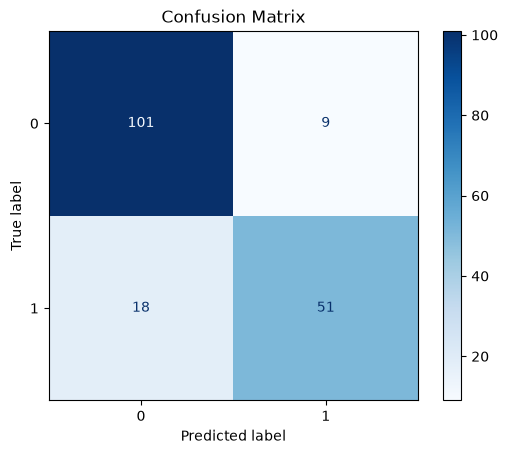

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_valid, preds, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [25]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["logistic_regression"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": abs(coefficients)
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Coefficient,Importance
4,cat__Title_clean_Mr,-2.034592,2.034592
6,cat__Title_clean_Other,-1.618448,1.618448
2,cat__Title_clean_Master,1.413357,1.413357
5,cat__Title_clean_Mrs,1.284685,1.284685
7,cat__Pclass_1,1.106388,1.106388
9,cat__Pclass_3,-1.028736,1.028736
3,cat__Title_clean_Miss,0.965410,0.965410
0,num__SibSp,-0.415820,0.415820
1,num__Parch,-0.227920,0.227920
8,cat__Pclass_2,-0.067239,0.067239


**Finding:** the coefficients read coherently. `Title_Mr` is the strongest negative predictor (−2.03), while `Master` (+1.41) and `Mrs` (+1.28) are strongly positive — the model has effectively recovered "women and children first" through the title feature alone; `Sex` never enters the model directly. First class adds to survival odds (+1.11), third class subtracts (−1.03), and larger family counts pull mildly negative.

In [26]:
from sklearn.base import clone
from sklearn.metrics import log_loss, accuracy_score
import matplotlib.pyplot as plt

c_values = [0.001, 0.01, 0.1, 1, 10, 100]

losses = []
accuracies = []

for c_value in c_values:
    model_c = clone(model)
    model_c.set_params(logistic_regression__C=c_value)

    model_c.fit(X_train, y_train)

    y_proba_c = model_c.predict_proba(X_valid)[:, 1]
    preds_c = model_c.predict(X_valid)

    losses.append(log_loss(y_valid, y_proba_c))
    accuracies.append(accuracy_score(y_valid, preds_c))

results = pd.DataFrame({
    "C": c_values,
    "Log loss": losses,
    "Accuracy": accuracies
})

results

,C,Log loss,Accuracy
0,0.001,0.642610,0.614525
1,0.010,0.539610,0.776536
2,0.100,0.440090,0.837989
3,1.000,0.422612,0.843575
4,10.000,0.423737,0.837989
5,100.000,0.424057,0.837989


**Finding:** `C = 1` is the sweet spot — lowest validation log loss (0.42) and highest accuracy.
Stronger regularization (`C ≤ 0.01`) visibly underfits; weaker regularization changes little,
consistent with a small, well-behaved feature set.

In [27]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.0, 1.05, 0.05)
result = []
for threshold in thresholds:
    predictions = (val_proba >= threshold).astype(int)

    precision = precision_score(y_valid, predictions, zero_division=0)
    recall = recall_score(y_valid, predictions, zero_division=0)
    f1 = f1_score(y_valid, predictions, zero_division=0)

    result.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

df_result = pd.DataFrame(result)
print(df_result)

    Threshold  Precision    Recall        F1
0        0.00   0.385475  1.000000  0.556452
1        0.05   0.388571  0.985507  0.557377
2        0.10   0.549550  0.884058  0.677778
3        0.15   0.570093  0.884058  0.693182
4        0.20   0.570093  0.884058  0.693182
5        0.25   0.648352  0.855072  0.737500
6        0.30   0.655556  0.855072  0.742138
7        0.35   0.682353  0.840580  0.753247
8        0.40   0.716049  0.840580  0.773333
9        0.45   0.850000  0.739130  0.790698
10       0.50   0.847458  0.724638  0.781250
11       0.55   0.844828  0.710145  0.771654
12       0.60   0.833333  0.652174  0.731707
13       0.65   0.860000  0.623188  0.722689
14       0.70   0.944444  0.492754  0.647619
15       0.75   0.939394  0.449275  0.607843
16       0.80   0.966667  0.420290  0.585859
17       0.85   0.952381  0.289855  0.444444
18       0.90   1.000000  0.275362  0.431818
19       0.95   0.000000  0.000000  0.000000
20       1.00   0.000000  0.000000  0.000000


**Finding:** F1 peaks at a threshold of **0.45** (0.79), trading a little recall for a
substantial precision gain over 0.40 — the basis for the custom threshold used in Stage 6.

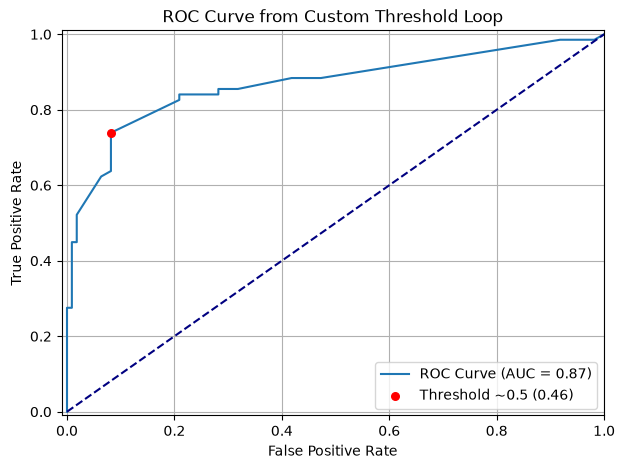

ROC_AUC Score: 0.868247694334651


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score


fpr, tpr, thresholds = roc_curve(y_valid, val_proba)
score = roc_auc_score(y_valid, val_proba)
closest_idx = np.argmin(np.abs(thresholds - 0.5))
closest_fpr = fpr[closest_idx]
closest_tpr = tpr[closest_idx]
closest_threshold = thresholds[closest_idx]

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {score:.2f})')
plt.scatter(closest_fpr, closest_tpr, color='red', marker='o', s=30, zorder = 5, label=f'Threshold ~0.5 ({closest_threshold:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([-0.01, 1])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve from Custom Threshold Loop')
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC_AUC Score: {score}")


**Finding:** ROC-AUC = 0.868 — discrimination holds across all thresholds, not just the chosen one. For scale, always predicting the majority class on this validation split would score 61.5%.

## Stage 8 — Extension: PyTorch Reimplementation with a Ticket-Group Embedding

The same model rebuilt in PyTorch as a single linear layer with sigmoid output (BCE loss, Adam),
plus one addition the scikit-learn version cannot express directly: a learned 3-dimensional
**embedding of the ticket code**, testing whether shared-ticket group membership carries signal
beyond the tabular features. Early stopping (patience 20) acts as regularization. Note this
extension uses its own unstratified split with the same seed, so its numbers are not directly
comparable to Stage 6 at decimal precision.

In [29]:
# Pytorch implementation
import torch
from torch import nn

df['Ticket_code'] = df['Ticket'].astype('category').cat.codes

num_feature = ["SibSp", "Parch"]
cat_feature = ['Title_clean', 'Pclass']

X = df[num_feature + cat_feature]
y = df['Survived']

X_train, X_valid, y_train, y_valid, ticket_train, ticket_valid = train_test_split(X, y, df['Ticket_code'], test_size=0.2, random_state=17)


preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)

X_train_tensor = torch.from_numpy(X_train_transformed).float()
X_valid_tensor = torch.from_numpy(X_valid_transformed).float()
ticket_train_tensor = torch.from_numpy(ticket_train.to_numpy()).long()
ticket_valid_tensor = torch.from_numpy(ticket_valid.to_numpy()).long()
y_train_tensor = torch.from_numpy(y_train.to_numpy()).float().view(-1,1)
y_valid_tensor = torch.from_numpy(y_valid.to_numpy()).float().view(-1,1)

C:\Users\kwtsu\AppData\Local\Temp\ipykernel_2832\1083212798.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  ticket_train_tensor = torch.from_numpy(ticket_train.to_numpy()).long()


In [30]:
# Sanity check
print(X_train_tensor.shape)
print(X_valid_tensor.shape)
print(ticket_train_tensor.shape)
print(ticket_valid_tensor.shape)
print(y_train_tensor.shape)
print(y_valid_tensor.shape)

torch.Size([712, 10])
torch.Size([179, 10])
torch.Size([712])
torch.Size([179])
torch.Size([712, 1])
torch.Size([179, 1])


Epoch: [10/1000], train loss: 0.6723, valid loss: 0.6770
Epoch: [20/1000], train loss: 0.6632, valid loss: 0.6692
Epoch: [30/1000], train loss: 0.6546, valid loss: 0.6617
Epoch: [40/1000], train loss: 0.6464, valid loss: 0.6545
Epoch: [50/1000], train loss: 0.6385, valid loss: 0.6477
Epoch: [60/1000], train loss: 0.6310, valid loss: 0.6412
Epoch: [70/1000], train loss: 0.6238, valid loss: 0.6350
Epoch: [80/1000], train loss: 0.6168, valid loss: 0.6291
Epoch: [90/1000], train loss: 0.6100, valid loss: 0.6235
Epoch: [100/1000], train loss: 0.6034, valid loss: 0.6182
Epoch: [110/1000], train loss: 0.5969, valid loss: 0.6131
Epoch: [120/1000], train loss: 0.5906, valid loss: 0.6084
Epoch: [130/1000], train loss: 0.5843, valid loss: 0.6038
Epoch: [140/1000], train loss: 0.5780, valid loss: 0.5995
Epoch: [150/1000], train loss: 0.5718, valid loss: 0.5955
Epoch: [160/1000], train loss: 0.5655, valid loss: 0.5916
Epoch: [170/1000], train loss: 0.5593, valid loss: 0.5880
Epoch: [180/1000], trai

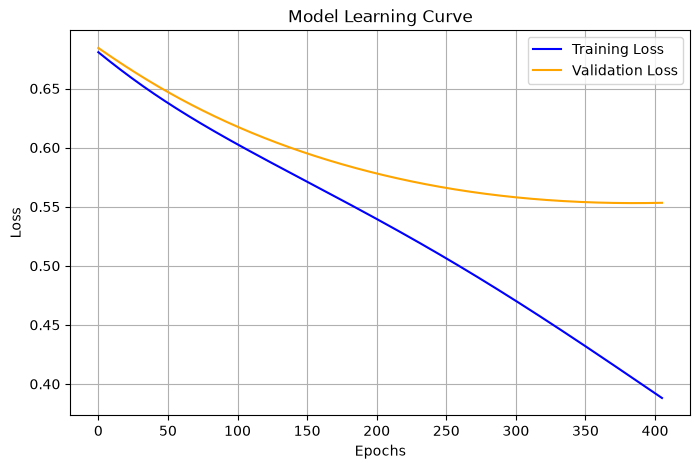

In [31]:
import copy
import torch.optim as optim
import matplotlib.pyplot as plt

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=681, embedding_dim=3)
        self.linear = nn.Linear(in_features= 13, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, ticket):
        embedded = self.embedding(ticket)
        x_clean = torch.cat((x, embedded), dim=1)
        logits = self.linear(x_clean) 
        probabilities = self.sigmoid(logits) 
        return probabilities

model = NeuralNetwork()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
num_epoch = 1000

history = {
    "train loss": [],
    "valid loss": []
}

best_val_loss = float('inf')
patience_counter = 0
best_weights = None

for epoch in range(num_epoch):
    model.train()
    optimizer.zero_grad()
    train_preds = model(X_train_tensor, ticket_train_tensor)
    train_loss = criterion(train_preds, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    history["train loss"].append(train_loss.item())
    

    model.eval()
    with torch.no_grad():
        valid_preds = model(X_valid_tensor, ticket_valid_tensor)
        valid_loss = criterion(valid_preds, y_valid_tensor)
        history['valid loss'].append(valid_loss.item())

    if valid_loss.item() < best_val_loss:
        best_val_loss = valid_loss.item()
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter == 20:
        break

    if (epoch + 1) %  10 == 0:
        print(f"Epoch: [{epoch+1}/{num_epoch}], "
              f"train loss: {train_loss:.4f}, "
              f"valid loss: {valid_loss:.4f}")

model.load_state_dict(best_weights)
plt.figure(figsize=(8, 5))
plt.plot(history["train loss"], label="Training Loss", color="blue")
plt.plot(history["valid loss"], label="Validation Loss", color="orange")
plt.title("Model Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Finding:** training stops early around epoch 350 with best validation loss ≈ 0.575 — clearly worse than the scikit-learn pipeline's 0.423. The embedding adds 2,043 learnable parameters (681 tickets × 3 dims) against 712 training rows, and most validation-set ticket codes never appear in training, so the embedding memorizes rather than generalizes. The negative result is informative: group-membership features need enough repeated group observations to transfer; a simple `Ticket_group` count would be the cheaper test.

## Stage 9 — Conclusions and Limitations

- **Outcome:** a four-feature logistic regression with a deliberately minimal, screened feature set reached 84.9% validation accuracy (AUC 0.868). Most engineered candidates — log fare, age bins, interactions, group features — were screened out rather than in; the value came from screening candidates out on evidence, not from adding more.
- **Negative results (removed from the main path):** an `SGDClassifier` trained with manual epochs matched but did not beat the closed-form solver (val loss 0.456 vs 0.423), and an `MLPClassifier` (hidden layers 15/10, L2 α = 0.01) collapsed to predicting the majority class (59.2% — exactly the majority rate of its split). With 712 training rows and 10 input features, added capacity consistently hurt. The PyTorch ticket embedding (Stage 8) repeated the pattern.
- **Caveats:** all headline figures come from a single stratified 80/20 split, and the 0.45 threshold was selected on the same validation split it is evaluated on (the default 0.5 threshold gives 84.4%); k-fold cross-validation would give more reliable estimates, and a validation-set accuracy is not directly comparable to Kaggle's hidden-test leaderboard scores.
- **Next steps:** cross-validated threshold selection, probability calibration, and testing ticket-group size as a plain count feature.